Section 1

In [20]:
import json
import pandas as pd

In [21]:
with open("C:\\Users\\Windows11\\Desktop\\AI Legal Contract Intelligence Platform\\cuad-main\\data\\CUADv1.json","r",encoding = "utf-8") as f:
    data = json.load(f)

print(type(data))
print(data.keys())

<class 'dict'>
dict_keys(['version', 'data'])


In [22]:
print(len(data["data"]))

510


In [23]:
data["data"][0].keys()

dict_keys(['title', 'paragraphs'])

In [24]:
data["data"][0]

{'title': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT',
 'paragraphs': [{'qas': [{'answers': [{'text': 'DISTRIBUTOR AGREEMENT',
       'answer_start': 44}],
     'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name',
     'question': 'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract',
     'is_impossible': False},
    {'answers': [{'text': 'Distributor', 'answer_start': 244},
      {'text': 'Electric City Corp.', 'answer_start': 148},
      {'text': 'Electric City of Illinois L.L.C.', 'answer_start': 49574},
      {'text': 'Company', 'answer_start': 197},
      {'text': 'Electric City of Illinois LLC', 'answer_start': 212}],
     'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Parties',
     'question': 'Highlight the parts (if any) of this contract related to "Parties" that should be reviewed by a lawyer. Details: The two or more parties who signed t

In [25]:
import pprint
pprint.pprint(data["data"][0])

{'paragraphs': [{'context': 'EXHIBIT 10.6\n'
                            '\n'
                            '                              DISTRIBUTOR '
                            'AGREEMENT\n'
                            '\n'
                            '         THIS  DISTRIBUTOR  AGREEMENT (the  '
                            '"Agreement")  is made by and between Electric '
                            'City Corp.,  a Delaware  corporation  '
                            '("Company")  and Electric City of Illinois LLC '
                            '("Distributor") this 7th day of September, 1999.\n'
                            '\n'
                            '                                    RECITALS\n'
                            '\n'
                            "         A. The  Company's  Business.  The "
                            'Company is  presently  engaged in the business  '
                            'of selling an energy  efficiency  device,  which '
                  

In [26]:
print(data["data"][0]["paragraphs"][0].keys())

dict_keys(['qas', 'context'])


In [27]:
print(len(data["data"][0]["paragraphs"][0]["qas"]))

41


In [28]:
print(data["data"][0]["paragraphs"][0]["qas"][0])

{'answers': [{'text': 'DISTRIBUTOR AGREEMENT', 'answer_start': 44}], 'id': 'LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGREEMENT__Document Name', 'question': 'Highlight the parts (if any) of this contract related to "Document Name" that should be reviewed by a lawyer. Details: The name of the contract', 'is_impossible': False}


Section 2: Creating a dataframe from the JSON

In [29]:
rows = []
for contract in data ["data"]:
    contract_title = contract["title"] 
    for paragraph in contract["paragraphs"]:
        context = paragraph["context"]
        for qa in paragraph["qas"]:
            clause_type = qa["id"].split("__")[-1]
            answer_text = ""
            if len(qa["answers"]) > 0:
                answer_text = qa["answers"][0]["text"]

            rows.append({
                "contract_title": contract_title,
                "clause_type": clause_type,
                "answer_text": answer_text,
                "question": qa["question"],
                "context": context
            })
df = pd.DataFrame(rows)

print(df.shape[0])
df.head()

20910


,contract_title,clause_type,answer_text,question,context
0,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Document Name,DISTRIBUTOR AGREEMENT,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
1,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Parties,Distributor,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
2,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Agreement Date,"7th day of September, 1999.",Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
3,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Effective Date,The term of this Agreement shall be ten (10)...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...
4,LIMEENERGYCO_09_09_1999-EX-10-DISTRIBUTOR AGRE...,Expiration Date,The term of this Agreement shall be ten (10)...,Highlight the parts (if any) of this contract ...,EXHIBIT 10.6\n\n ...


In [30]:
print(df["clause_type"].nunique())

41


In [31]:
print(df["clause_type"].value_counts().head(20))

clause_type
Document Name                         510
Parties                               510
Agreement Date                        510
Effective Date                        510
Expiration Date                       510
Renewal Term                          510
Notice Period To Terminate Renewal    510
Governing Law                         510
Most Favored Nation                   510
Non-Compete                           510
Exclusivity                           510
No-Solicit Of Customers               510
Competitive Restriction Exception     510
No-Solicit Of Employees               510
Non-Disparagement                     510
Termination For Convenience           510
Rofr/Rofo/Rofn                        510
Change Of Control                     510
Anti-Assignment                       510
Revenue/Profit Sharing                510
Name: count, dtype: int64


Section 3: EDA

In [ ]:
print(df.shape)

(20910, 5)


In [ ]:
#Missing Clauses
df["answer_text"] = df["answer_text"].fillna("")

missing_pct = (
    df["answer_text"].str.len() ==0
).mean() * 100

print(f"Missing Clauses: {missing_pct:.2f}%")

Missing Clauses: 67.95%


In [ ]:
#Top Existing Clauses
df["has_clause"] = df["answer_text"].str.len() > 0

clause_presence = (
    df.groupby("clause_type")["has_clause"]
    .sum()
    .sort_values(ascending=False)
)

print(clause_presence.head(20))

clause_type
Document Name                  510
Parties                        509
Agreement Date                 470
Governing Law                  437
Expiration Date                413
Effective Date                 390
Anti-Assignment                374
Cap On Liability               275
License Grant                  255
Audit Rights                   214
Termination For Convenience    183
Post-Termination Services      182
Exclusivity                    180
Renewal Term                   176
Insurance                      166
Revenue/Profit Sharing         166
Minimum Commitment             165
Non-Transferable License       138
Ip Ownership Assignment        124
Change Of Control              121
Name: has_clause, dtype: int64


In [ ]:
# Top Existing Clause
df["has_clause"] = df["answer_text"].str.len() > 0

clause_presence = (
    df.groupby("clause_type")["has_clause"]
    .sum()
    .sort_values(ascending=False)
)

print(clause_presence.head(20))

clause_type
Document Name                  510
Parties                        509
Agreement Date                 470
Governing Law                  437
Expiration Date                413
Effective Date                 390
Anti-Assignment                374
Cap On Liability               275
License Grant                  255
Audit Rights                   214
Termination For Convenience    183
Post-Termination Services      182
Exclusivity                    180
Renewal Term                   176
Insurance                      166
Revenue/Profit Sharing         166
Minimum Commitment             165
Non-Transferable License       138
Ip Ownership Assignment        124
Change Of Control              121
Name: has_clause, dtype: int64


In [ ]:
multiple_answers = 0

for contract in data["data"]:
    for paragraph in contract["paragraphs"]:
        for qa in paragraph["qas"]:
            if len(qa["answers"]) > 1:
                multiple_answers += 1

print("Questions with multiple answers:", multiple_answers)

Questions with multiple answers: 2605


In [38]:
ml_df = df[df["answer_text"].str.len() > 20].copy()

print(ml_df.shape)

(5790, 6)


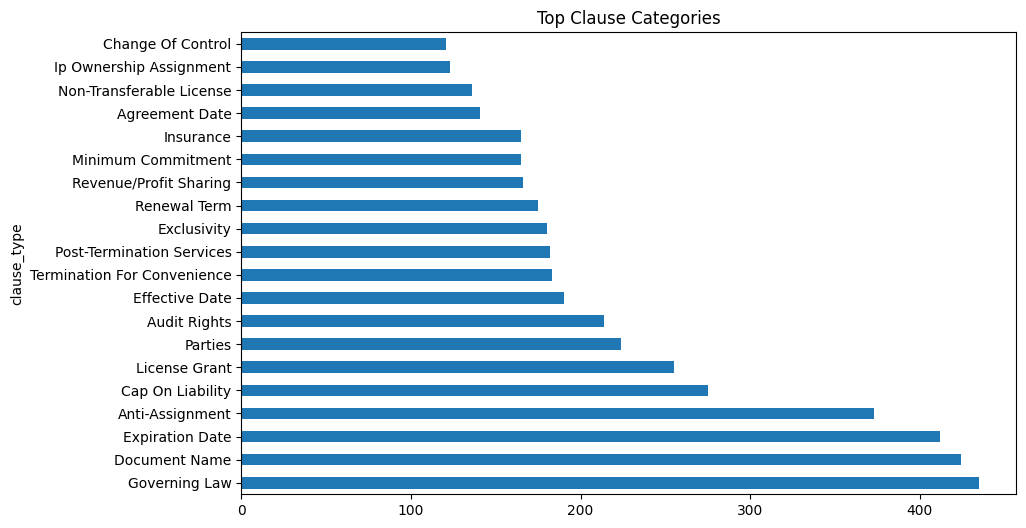

In [39]:
#Top Clause Types
import matplotlib.pyplot as plt

ml_df["clause_type"].value_counts().head(20).plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Top Clause Categories")
plt.show()

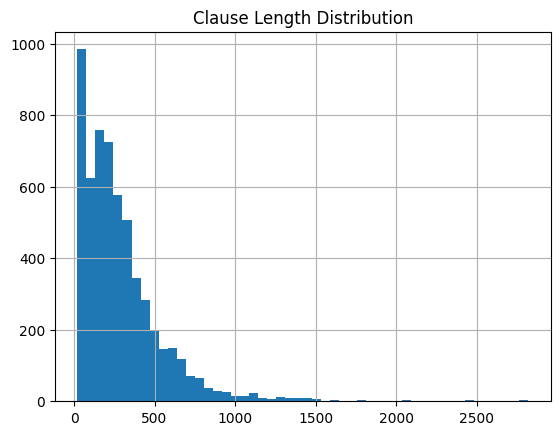

In [40]:
# Clause Length Distribution
ml_df["clause_length"] = (ml_df["answer_text"].str.len())

ml_df["clause_length"].hist(bins=50)

plt.title("Clause Length Distribution")
plt.show()

In [41]:
print(ml_df.shape)

(5790, 7)


In [42]:
print(ml_df["clause_type"].value_counts())

clause_type
Governing Law                         435
Document Name                         424
Expiration Date                       412
Anti-Assignment                       373
Cap On Liability                      275
License Grant                         255
Parties                               224
Audit Rights                          214
Effective Date                        190
Termination For Convenience           183
Post-Termination Services             182
Exclusivity                           180
Renewal Term                          175
Revenue/Profit Sharing                166
Minimum Commitment                    165
Insurance                             165
Agreement Date                        141
Non-Transferable License              136
Ip Ownership Assignment               123
Change Of Control                     121
Non-Compete                           119
Uncapped Liability                    111
Notice Period To Terminate Renewal    110
Covenant Not To Sue   

In [43]:
# Important Observation
# dataset is imbalanced.
# Some classes: 435 samples
# Others: 13 samples

In [44]:
# Removing Very Rare Classes

In [45]:
class_counts = ml_df["clause_type"].value_counts()

valid_class = class_counts[class_counts>= 30].index

ml_df_filtered = ml_df[ml_df["clause_type"].isin(valid_class)].copy()
print(ml_df_filtered.shape)
print(ml_df_filtered["clause_type"].nunique())

(5694, 7)
36


In [46]:
ml_df_filtered.to_csv(
    "processed_clause_dataset.csv",
    index=False
)